In [30]:
# 1. Load library
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from mgwr.gwr import GWR, MGWR
from mgwr.sel_bw import Sel_BW
from pysal.explore import esda
from pysal.lib import weights
from splot.esda import plot_moran
import contextily as ctx

from shapely.geometry import MultiPolygon

In [ ]:
# 2. Load data
gdf = gpd.read_file("C:/Uner/Semester 4/Analisis Data Spasial/UTS/gadm41_IDN_1.shp")
data = pd.read_excel("C:/Uner/Semester 4/Analisis Data Spasial/Kuis, Tugas, UAS/Data Spasial_Kelompok 9.xlsx")
print(data.columns)

Index([ 'PROVINSI',    'Datang', 'Berangkat',     'Mikro',     'Kecil',
                 1,           2,           3,           4,           5,
                 6,           7,           8,           9,          10,
                11,          12,          13,          14,          15,
                16,          17,          18,          19,          20,
                21,          22,          23,          24,          25,
                26,          27,          28,          29,          30,
                31,          32,          33,          34,          35,
                36,          37,          38,          39,          40,
                41,          42,          43,          44,          45,
                46,          47,          48,          49,          50,
                51,          52,          53,          54,          55,
                56,          57,          58,          59,          60],
      dtype='object')


NameError: name 'v' is not defined

In [ ]:
# --- 2. Aggregate Monthly Data ---
data["jumlah_wisatawan_nusantara"] = data.loc[:, data.columns[1:13]].sum(axis=1)
data["jumlah_penumpang_pesawat"] = data.loc[:, data.columns[13:25]].sum(axis=1)
data["pengeluaran_industri"] = data.loc[:, data.columns[25:37]].sum(axis=1)

# Clean provinsi name
data["prov_clean"] = data["PROVINSI"].str.upper().str.replace("PROVINSI ", "", regex=False)
data["prov_clean"] = data["prov_clean"].str.replace("DAERAH KHUSUS IBUKOTA ", "", regex=False)
data["prov_clean"] = data["prov_clean"].str.replace("DKI JAKARTA", "JAKARTA")
data["prov_clean"] = data["prov_clean"].str.replace("DI YOGYAKARTA", "YOGYAKARTA")
data["prov_clean"] = data["prov_clean"].str.replace("NANGGROE ACEH DARUSSALAM", "ACEH")

In [ ]:
def ensure_polygons(geom):
    if isinstance(geom, MultiPolygon):
        return max(geom.geoms, key=lambda a: a.area)
    return geom

gdf["geometry"] = gdf["geometry"].apply(ensure_polygons)
gdf = gdf.set_geometry("geometry")

# Clean province names in shapefile
gdf["prov_clean"] = gdf["NAME_1"].str.upper()
gdf["prov_clean"] = gdf["prov_clean"].str.replace("JAKARTA RAYA", "JAKARTA")
gdf["prov_clean"] = gdf["prov_clean"].str.replace("KEPULAUAN RIAU", "KEP. RIAU")
gdf["prov_clean"] = gdf["prov_clean"].str.replace("BANGKA BELITUNG", "KEP. BANGKA BELITUNG")
gdf["prov_clean"] = gdf["prov_clean"].str.replace("DAERAH ISTIMEWA YOGYAKARTA", "YOGYAKARTA")


In [ ]:
# --- 4. Merge Spatial and Tabular Data ---
gdf_merged = gdf.merge(data, on="prov_clean", how="left")
gdf_merged = gdf_merged.dropna(subset=["jumlah_wisatawan_nusantara", "jumlah_penumpang_pesawat", "pengeluaran_industri"])

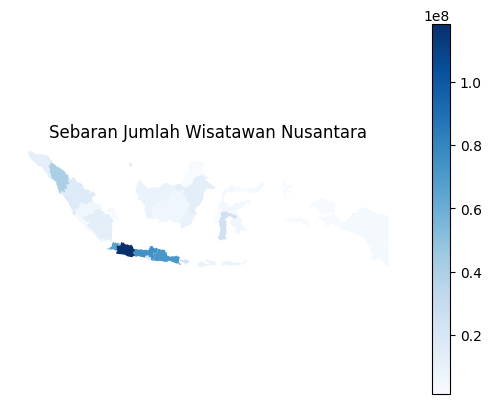

In [ ]:
# --- 5. Plot Maps ---
gdf_merged.plot(column="jumlah_wisatawan_nusantara", cmap="Blues", legend=True)
plt.title("Sebaran Jumlah Wisatawan Nusantara")
plt.axis("off")
plt.show()

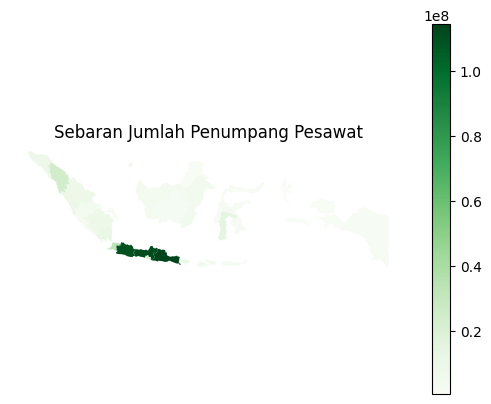

In [ ]:
gdf_merged.plot(column="jumlah_penumpang_pesawat", cmap="Greens", legend=True)
plt.title("Sebaran Jumlah Penumpang Pesawat")
plt.axis("off")
plt.show()

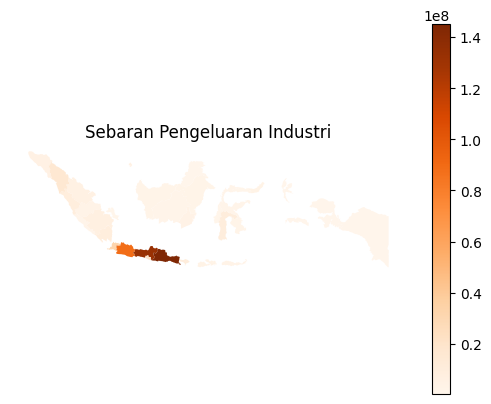

In [ ]:
gdf_merged.plot(column="pengeluaran_industri", cmap="Oranges", legend=True)
plt.title("Sebaran Pengeluaran Industri")
plt.axis("off")
plt.show()

In [ ]:
import statsmodels.api as sm

# Persiapkan variabel dependen dan independen
y = gdf_merged["jumlah_wisatawan_nusantara"]
X = gdf_merged[["jumlah_penumpang_pesawat", "pengeluaran_industri"]]
X = sm.add_constant(X)

# Fit model
ols_model = sm.OLS(y, X).fit()
print(ols_model.summary())


                                OLS Regression Results                                
Dep. Variable:     jumlah_wisatawan_nusantara   R-squared:                       0.947
Model:                                    OLS   Adj. R-squared:                  0.944
Method:                         Least Squares   F-statistic:                     278.8
Date:                        Sat, 21 Jun 2025   Prob (F-statistic):           1.52e-20
Time:                                16:39:31   Log-Likelihood:                -578.96
No. Observations:                          34   AIC:                             1164.
Df Residuals:                              31   BIC:                             1169.
Df Model:                                   2                                         
Covariance Type:                    nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------

In [ ]:
import libpysal
from esda import Moran
import numpy as np

# Konversi geometri ke centroid
gdf_merged["centroid"] = gdf_merged.geometry.centroid
coords = np.array([(geom.x, geom.y) for geom in gdf_merged["centroid"]])

# Buat spatial weights pakai Queen contiguity
w = libpysal.weights.Queen.from_dataframe(gdf_merged)
w.transform = 'r'

# Hitung residual dari model OLS
gdf_merged["residuals"] = ols_model.resid

# Moran’s I untuk residual
moran_resid = Moran(gdf_merged["residuals"], w)
print(f"Moran's I: {moran_resid.I:.4f}, p-value: {moran_resid.p_sim:.4f}")


C:\Users\Faiz Iqbal\AppData\Local\Temp\ipykernel_6500\63863847.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_merged["centroid"] = gdf_merged.geometry.centroid
C:\Users\Faiz Iqbal\AppData\Local\Temp\ipykernel_6500\63863847.py:10: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = libpysal.weights.Queen.from_dataframe(gdf_merged)


('WARNING: ', 1, ' is an island (no neighbors)')
('WARNING: ', 2, ' is an island (no neighbors)')
('WARNING: ', 16, ' is an island (no neighbors)')
('WARNING: ', 18, ' is an island (no neighbors)')
('WARNING: ', 19, ' is an island (no neighbors)')
('WARNING: ', 20, ' is an island (no neighbors)')
('WARNING: ', 21, ' is an island (no neighbors)')
Moran's I: -0.2390, p-value: 0.0320


c:\Users\Faiz Iqbal\AppData\Local\Programs\Python\Python311\Lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 7 islands with ids: 1, 2, 16, 18, 19, 20, 21.
  W.__init__(self, neighbors, ids=ids, **kw)


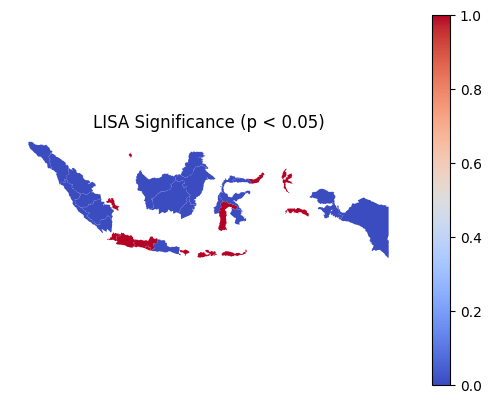

In [ ]:
from esda.moran import Moran_Local
import matplotlib.pyplot as plt

# LISA untuk variable target
lisa = Moran_Local(gdf_merged["jumlah_wisatawan_nusantara"], w)

# Tambahkan hasil ke dataframe
gdf_merged["LISA_I"] = lisa.Is
gdf_merged["LISA_p"] = lisa.p_sim
gdf_merged["LISA_sig"] = (gdf_merged["LISA_p"] < 0.05).astype(int)

# Visualisasi LISA significance
gdf_merged.plot(column="LISA_sig", cmap="coolwarm", legend=True)
plt.title("LISA Significance (p < 0.05)")
plt.axis("off")
plt.show()


In [ ]:
import numpy as np
from mgwr.gwr import GWR, MGWR
from mgwr.sel_bw import Sel_BW
from mgwr.utils import shift_colormap
from sklearn.preprocessing import StandardScaler

# Pastikan tidak menambahkan kolom intercept manual di X, karena constant=True
k = X.shape[1] + 1  # karena MGWR akan menambahkan intercept

# Atur batas bandwidth untuk masing-masing variabel (termasuk intercept)
multi_bw_min = [2] * k
multi_bw_max = [30] * k

# --- Seleksi bandwidth MGWR ---
selector = Sel_BW(coords, y, X, multi=True, constant=True)
multi_bw = selector.search(
    multi_bw_min=multi_bw_min,
    multi_bw_max=multi_bw_max
)

print("Bandwidth MGWR:", multi_bw)

# --- Fit MGWR ---
mgwr_model = MGWR(coords, y, X, multi_bw, constant=True).fit()

# --- Tambahkan hasil parameter ke GeoDataFrame ---
for i in range(k):
    gdf_merged[f"MGWR_coef_{i}"] = mgwr_model.params[:, i]

gdf_merged["MGWR_R2"] = mgwr_model.localR2

# --- Ringkasan model ---
print(mgwr_model.summary())


ValueError: kth(=50) out of bounds (34)